# Assignment 1 — Data and Probability Foundations

## Group members

- Bibek Chaudhary (344326)
- Samo Susa (343876)
- Sneha Koirala (345788)
- Tomas Psotka (343207)

## Table of contents

1. [Imports and display settings](#Imports-and-display-settings)
2. [Part 1 — Digital services](#Part-1-—-Digital-services)
   1. [1.1 Load and inspect the dataset](#1.1-Load-and-inspect-the-dataset)
   2. [1.2 Frequency table for `alert_type`](#1.2-Frequency-table-for-`alert_type`)
   3. [1.3 Descriptive statistics for `latency_ms`](#1.3-Descriptive-statistics-for-`latency_ms`)
   4. [1.4 Histogram of all latency measurements](#1.4-Histogram-of-all-latency-measurements)
   5. [1.5 Side-by-side boxplots for the services](#1.5-Side-by-side-boxplots-for-the-services)
   6. [1.6 Potential outliers using the $1.5\times\operatorname{IQR}$ rule](#1.6-Potential-outliers-using-the-$1.5\times\operatorname{IQR}$-rule)
   7. [1.7 Descriptive comparison of the services](#1.7-Descriptive-comparison-of-the-services)
   8. [1.8 Part 1 conclusion](#1.8-Part-1-conclusion)
3. [Part 2 — Smart-building measurements](#Part-2-—-Smart-building-measurements)
   1. [2.1 Observational unit, variables and grouped summaries](#2.1-Observational-unit,-variables-and-grouped-summaries)
   2. [2.2 Indoor temperature over time](#2.2-Indoor-temperature-over-time)
   3. [2.3 Outdoor temperature and energy use](#2.3-Outdoor-temperature-and-energy-use)
   4. [2.4 Part 2 conclusion](#2.4-Part-2-conclusion)
4. [Part 3 — Cybersecurity alert system](#Part-3-—-Cybersecurity-alert-system)
   1. [3.1 Elementary outcomes](#3.1-Elementary-outcomes)
   2. [3.2 Expected-count table](#3.2-Expected-count-table)
   3. [3.3 Probability calculations](#3.3-Probability-calculations)
   4. [3.4 Conditional probability, independence and mutual exclusivity](#3.4-Conditional-probability,-independence-and-mutual-exclusivity)
   5. [3.5 Improved alert system](#3.5-Improved-alert-system)
5. [Part 4 — AI use and overall conclusion](#Part-4-—-AI-use-and-overall-conclusion)
   1. [AI-use statement](#AI-use-statement)
   2. [Overall conclusion](#Overall-conclusion)


## Imports and display settings

Only methods from Sessions 1–2 are used. Pandas handles the tables and descriptive statistics, while Matplotlib creates the plots. NumPy, SciPy, Seaborn, correlation, regression, confidence intervals, and hypothesis tests are not needed here.


In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    # This fallback is useful if the code is tested as a normal Python script.
    display = print

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")


# Part 1 — Digital services

## 1.1 Load and inspect the dataset

The assignment asks us to read the file from a local `data` folder. The small fallback list below also allows the notebook to work if it is saved directly inside that folder or one level below it.


In [ ]:
candidate_paths = [
    Path("data/assignment01_digital_services.csv"),
    Path("../data/assignment01_digital_services.csv"),
    Path("assignment01_digital_services.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find assignment01_digital_services.csv. "
        "Place it in a data folder next to this notebook."
    )

digital_services = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print(f"Rows: {len(digital_services)}, Columns: {digital_services.shape[1]}")
display(digital_services.head())


Loaded: ..\data\assignment01_digital_services.csv
Rows: 144, Columns: 4


,observation_id,service,latency_ms,alert_type
0,1,orders,112.70,none
1,2,orders,109.83,none
2,3,telemetry,99.02,none
3,4,telemetry,94.44,none
4,5,telemetry,97.09,none


In [ ]:
print("Column data types:")
display(digital_services.dtypes.rename("Data type").to_frame())

print("Missing values per column:")
display(digital_services.isna().sum().rename("Missing values").to_frame())

print("Number of duplicated observation IDs:")
print(digital_services["observation_id"].duplicated().sum())


Column data types:


,Data type
observation_id,int64
service,str
latency_ms,float64
alert_type,str


Missing values per column:


,Missing values
observation_id,0
service,0
latency_ms,0
alert_type,0


Number of duplicated observation IDs:
0


### Observational unit, population and variables

The **observational unit** is one recorded digital-service observation: one row gives the service involved, its measured latency and the alert category associated with that observation.

The **sample** is the 144 observations in the supplied CSV file. The relevant **population** is all comparable observations from these three digital services in the operating environment and period that the sample is intended to represent. Because the file does not describe a random-sampling design or a wider time frame, generalisation beyond the supplied observations must be cautious.

| Variable | Classification | Reason |
|---|---|---|
| `observation_id` | Categorical identifier | Its numbers label observations; arithmetic on the labels has no useful meaning. |
| `service` | Categorical | It places an observation into a service category: identity, orders or telemetry. |
| `latency_ms` | Quantitative, continuous | It measures elapsed time numerically in milliseconds. |
| `alert_type` | Categorical | It records the alert category, including `none`. |

Although `observation_id` contains integers, it is not a quantitative measurement. For example, ID 100 does not represent twice as much of anything as ID 50.


## 1.2 Frequency table for `alert_type`

Counts tell us how many observations belong to each category. Percentages express each count as a proportion of all 144 observations.


In [ ]:
alert_counts = digital_services["alert_type"].value_counts()

alert_frequency = pd.DataFrame({
    "Count": alert_counts,
    "Percentage": alert_counts / len(digital_services) * 100,
})

alert_frequency.loc["Total"] = [
    alert_frequency["Count"].sum(),
    alert_frequency["Percentage"].sum(),
]

alert_frequency["Count"] = alert_frequency["Count"].astype(int)
display(alert_frequency.round(2))


,Count,Percentage
alert_type,,
none,104,72.22
authentication,25,17.36
rate_limit,9,6.25
injection_signature,6,4.17
Total,144,100.00


### Interpretation

The category `none` is the most frequent, with 104 observations (72.22%). Among actual alert categories, `authentication` is the most frequent with 25 observations (17.36%), followed by `rate_limit` with 9 (6.25%). `injection_signature` is the least frequent category with 6 observations (4.17%). These percentages describe the composition of this sample; they do not explain why the categories occur at different frequencies.


## 1.3 Descriptive statistics for `latency_ms`

For each group we calculate the sample size, mean, median, sample standard deviation, minimum, first quartile ($Q_1$), third quartile ($Q_3$), maximum and interquartile range.

$$\operatorname{IQR}=Q_3-Q_1$$

The standard deviation uses $n-1$ in the denominator. In Pandas this is made explicit with `std(ddof=1)`.


In [ ]:
def summarise_latency(values):
    # Return the descriptive statistics requested in the assignment.
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    return pd.Series({
        "n": values.count(),
        "Mean": values.mean(),
        "Median": values.median(),
        "Sample SD": values.std(ddof=1),
        "Minimum": values.min(),
        "Q1": q1,
        "Q3": q3,
        "Maximum": values.max(),
        "IQR": q3 - q1,
    })


overall_stats = summarise_latency(
    digital_services["latency_ms"]
).to_frame().T
overall_stats.index = ["All observations"]

service_stats = pd.DataFrame({
    service: summarise_latency(group["latency_ms"])
    for service, group in digital_services.groupby("service")
}).T

latency_statistics = pd.concat([overall_stats, service_stats])
latency_statistics["n"] = latency_statistics["n"].astype(int)

display(latency_statistics.round(2))


,n,Mean,Median,Sample SD,Minimum,Q1,Q3,Maximum,IQR
All observations,144,110.11,106.93,23.10,75.21,95.84,116.88,223.80,21.04
identity,49,96.07,93.72,16.12,75.21,85.39,105.10,154.27,19.71
orders,50,122.20,114.52,24.81,98.53,109.84,124.15,223.80,14.31
telemetry,45,111.97,106.92,19.38,86.78,97.95,116.83,177.87,18.88


### Interpretation

Across all 144 observations, the mean latency is 110.11 ms and the median is 106.93 ms. The overall sample standard deviation is 23.10 ms, and the middle 50% of observations span an IQR of 21.04 ms, from 95.85 ms to 116.88 ms.

The identity service has the lowest typical latency (mean 96.07 ms; median 93.72 ms). Orders has the highest typical latency (mean 122.20 ms; median 114.53 ms), while telemetry lies between them (mean 111.97 ms; median 106.92 ms). Orders also has the largest sample standard deviation at 24.81 ms. However, its IQR is the smallest at 14.31 ms. This combination suggests that the middle half of orders observations is fairly concentrated, while several unusually high values enlarge its overall standard deviation and range.


## 1.4 Histogram of all latency measurements


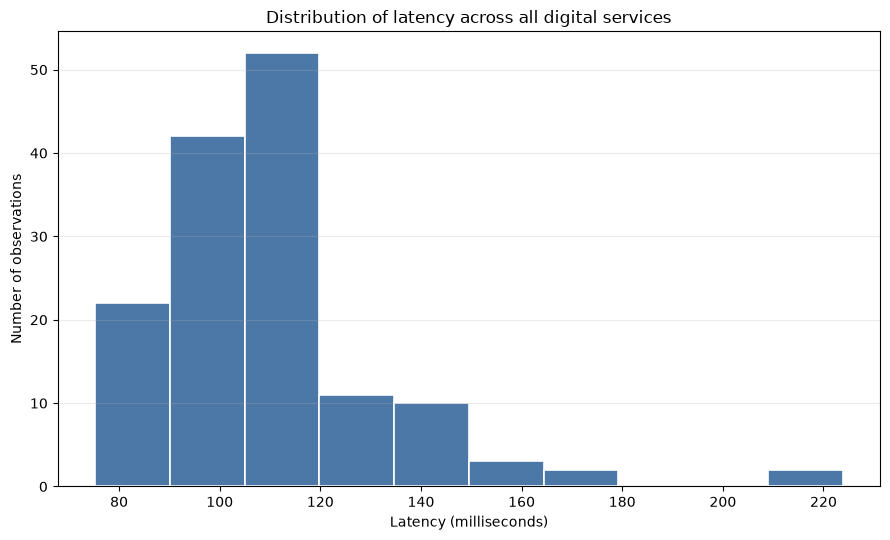

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(
    digital_services["latency_ms"],
    bins=10,
    color="#4C78A8",
    edgecolor="white",
    linewidth=1.2,
)

ax.set_title("Distribution of latency across all digital services")
ax.set_xlabel("Latency (milliseconds)")
ax.set_ylabel("Number of observations")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Histogram interpretation

The horizontal axis shows latency in milliseconds, and the vertical axis shows the number of observations. Each bar is a **bin**, meaning an interval of latency values rather than one exact value. The height of a bar is the number of observations whose latency falls inside that interval.

Most observations are concentrated in the lower latency intervals, roughly around 85–125 ms, while a small number of observations extend toward much higher values, up to 223.80 ms. The distribution therefore has a long right tail and appears **right-skewed**. The fact that the overall mean (110.11 ms) is above the median (106.93 ms) is consistent with high values pulling the mean upward. Changing the number of bins could change how detailed the shape looks, although it would not change the observations themselves.


## 1.5 Side-by-side boxplots for the services


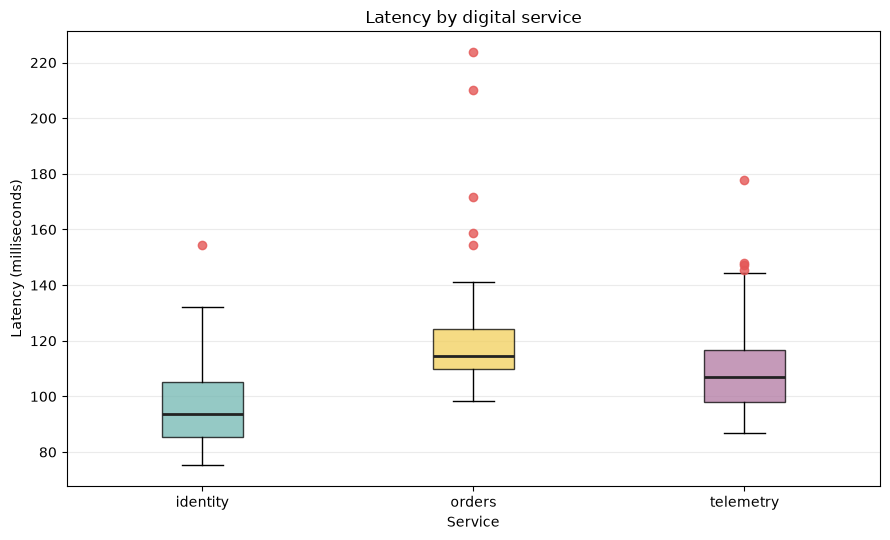

In [ ]:
service_order = ["identity", "orders", "telemetry"]
latency_by_service = [
    digital_services.loc[
        digital_services["service"] == service,
        "latency_ms",
    ]
    for service in service_order
]

fig, ax = plt.subplots(figsize=(9, 5.5))

boxplot = ax.boxplot(
    latency_by_service,
    tick_labels=service_order,
    patch_artist=True,
    medianprops={"color": "#222222", "linewidth": 2},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#E45756",
        "markeredgecolor": "#E45756",
        "alpha": 0.8,
    },
)

for box, colour in zip(
    boxplot["boxes"],
    ["#72B7B2", "#F2CF5B", "#B279A2"],
):
    box.set_facecolor(colour)
    box.set_alpha(0.75)

ax.set_title("Latency by digital service")
ax.set_xlabel("Service")
ax.set_ylabel("Latency (milliseconds)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Boxplot interpretation

The line inside each box is the **median**. The bottom and top of the box are $Q_1$ and $Q_3$, so the box contains the middle 50% of the observations and its height equals the IQR. The whiskers extend to the most extreme observed values that remain within the $1.5\times\operatorname{IQR}$ fences. Individually plotted points beyond the whiskers are **potential outliers**.

Identity has the lowest median, telemetry is in the middle, and orders has the highest median. The upper sides and individually plotted high points are more extended than the lower sides, particularly for orders and telemetry. This visual evidence supports right-skewness. The unusually high points will be identified exactly in the next section rather than estimated from the picture.


## 1.6 Potential outliers using the $1.5\times\operatorname{IQR}$ rule

The fences are calculated separately within each service:

$$\text{Lower fence}=Q_1-1.5(\operatorname{IQR})$$

$$\text{Upper fence}=Q_3+1.5(\operatorname{IQR})$$

An observation below the lower fence or above the upper fence is reported as a potential outlier.


In [ ]:
boundary_rows = []
outlier_frames = []

for service, group in digital_services.groupby("service"):
    q1 = group["latency_ms"].quantile(0.25)
    q3 = group["latency_ms"].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    boundary_rows.append({
        "Service": service,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower fence": lower_fence,
        "Upper fence": upper_fence,
    })

    service_outliers = group.loc[
        (group["latency_ms"] < lower_fence)
        | (group["latency_ms"] > upper_fence),
        ["observation_id", "service", "latency_ms"],
    ].copy()

    service_outliers["Lower fence"] = lower_fence
    service_outliers["Upper fence"] = upper_fence
    outlier_frames.append(service_outliers)


outlier_boundaries = pd.DataFrame(boundary_rows).set_index("Service")
potential_outliers = (
    pd.concat(outlier_frames, ignore_index=True)
    .sort_values(["service", "latency_ms"])
)

print("Service-specific outlier fences:")
display(outlier_boundaries.round(2))

print(f"Potential outliers found: {len(potential_outliers)}")
display(potential_outliers.round(2))


Service-specific outlier fences:


,Q1,Q3,IQR,Lower fence,Upper fence
Service,,,,,
identity,85.39,105.10,19.71,55.83,134.66
orders,109.84,124.15,14.31,88.37,145.61
telemetry,97.95,116.83,18.88,69.63,145.15


Potential outliers found: 10


,observation_id,service,latency_ms,Lower fence,Upper fence
0,132,identity,154.27,55.83,134.66
4,87,orders,154.32,88.37,145.61
3,66,orders,158.59,88.37,145.61
2,60,orders,171.59,88.37,145.61
1,19,orders,210.10,88.37,145.61
5,88,orders,223.80,88.37,145.61
7,39,telemetry,145.52,69.63,145.15
6,33,telemetry,147.26,69.63,145.15
8,120,telemetry,147.79,69.63,145.15
9,133,telemetry,177.87,69.63,145.15


### Outlier results and interpretation

The service-specific IQR rule identifies ten potential outliers, all above their service's upper fence:

- **Identity:** observation 132 (154.27 ms)
- **Orders:** observations 87 (154.32 ms), 66 (158.59 ms), 60 (171.59 ms), 19 (210.10 ms), and 88 (223.80 ms)
- **Telemetry:** observations 39 (145.52 ms), 33 (147.26 ms), 120 (147.79 ms), and 133 (177.87 ms)

The observations are retained in the analysis. A value beyond an IQR fence is not automatically a data error; it is a value that is unusually far from the middle 50% according to this rule. A high latency could be a genuine measurement caused by temporary congestion, server load, a slow dependency or another unusual operating condition. We would need contextual information, logs or evidence of a measurement problem before changing or removing it.


## 1.7 Descriptive comparison of the services

Identity has the lowest observed typical latency: its median is 93.72 ms and its mean is 96.07 ms. Orders has the highest observed typical latency, with a median of 114.53 ms and a mean of 122.20 ms. Telemetry is between these services, with a median of 106.92 ms and a mean of 111.97 ms.

Orders has the largest sample standard deviation (24.81 ms) and range, but the smallest IQR (14.31 ms). Its central observations are therefore relatively concentrated, while its five high potential outliers strongly increase the overall spread. Identity has the smallest standard deviation (16.12 ms), and telemetry has intermediate variability (19.38 ms).

For every service, the mean is higher than the median. Together with the longer upper tails and high potential outliers in the boxplots, this suggests right-skewness, most clearly for orders. These are descriptive differences in the supplied sample. They do not prove what caused the differences, that one service is inherently better, or that exactly the same pattern applies to all future observations or a wider population.


## 1.8 Part 1 conclusion

The 144 digital-service observations show clear descriptive differences among identity, orders and telemetry. Identity had the lowest typical latency, orders the highest, and telemetry lay between them. Orders had the greatest sample standard deviation, although its relatively small IQR shows that much of its additional spread came from high, unusual observations rather than from the middle half of its measurements. The histogram and boxplots indicate right-skewed latency distributions, which is also consistent with each service's mean being higher than its median. The service-specific $1.5\times\operatorname{IQR}$ rule identified ten potential outliers. They were retained because a statistically unusual value can represent genuine service behaviour and is not automatically a recording error. These results summarise the centre, spread and shape of the supplied observations only. Without information about sampling, operating conditions or possible explanatory factors, the analysis cannot establish causes or guarantee that the same differences hold in the wider population.


# Part 2 — Smart-building measurements

## 2.1 Observational unit, variables and grouped summaries


a. Identify the observational unit and variables. For indoor_temp_c and energy_kwh, report n, mean, median, and sample standard deviation separately for each zone.

Variables:

| Variable | Type | Justification |
|---|---|---|
| `measurement_id` | Identifier | A row label, so it is not summarised statistically. |
| `hour` | Quantitative (discrete) | It is a numeric variable that only takes whole-number values (1–24, repeated across the two recorded days), so it is discrete rather than continuous. It doesn't behave like a typical measurement, though — it records when each observation was taken rather than measuring a physical quantity of interest. So while it is quantitative by type, its role in this analysis is as a time/order variable: it's used to sequence the data and plot other variables (like indoor_temp_c) against it, rather than being summarised with a mean or median itself. |
| `zone` | Categorical | A label, such as north or south, compared by grouping rather than averaging. |
| `outdoor_temp_c` | Quantitative (continuous) | A numeric temperature measurement in degrees Celsius. |
| `indoor_temp_c` | Quantitative (continuous) | A numeric temperature measurement in degrees Celsius; its mean, median, standard deviation and quartiles are meaningful. |
| `energy_kwh` | Quantitative (continuous) | A numeric energy measurement in kilowatt-hours; its mean, median, standard deviation and quartiles are meaningful. |

In [1]:
DATA = Path("../data")
df_sb = pd.read_csv(DATA / "assignment01_smart_building.csv")

# Reusable function so we don't repeat code for each variable
def zone_summary(df, col):
    return (
        df.groupby("zone")[col]
        .agg(
            n="size",
            mean="mean",
            median="median",
            std_sample="std",
            
        )
    )

indoor_temp_summary = zone_summary(df_sb, "indoor_temp_c")
energy_summary = zone_summary(df_sb, "energy_kwh")

print("Indoor temperature (°C) by zone:")
display(indoor_temp_summary)

print("Energy (kWh) by zone:")
display(energy_summary)

Indoor temperature (°C) by zone:


,n,mean,median,std_sample
zone,,,,
north,48,21.276458,21.240,0.614563
south,48,22.267083,22.285,0.548208


Energy (kWh) by zone:


,n,mean,median,std_sample
zone,,,,
north,48,39.446458,39.84,3.975399
south,48,37.331042,37.08,4.151442


Intrepretation: Both zones have 48 hourly observations, consistent with two full days of monitoring. For indoor temperature, south is on average about 1°C warmer than north (mean 22.27°C vs. 21.28°C, median 22.29°C vs. 21.24°C), and both zones show low variability (sample SD of 0.55–0.61°C), indicating that indoor temperature is kept fairly stable within each zone across the two days.

For energy consumption, north uses slightly more energy on average than south (mean 39.45 kWh vs. 37.33 kWh), and both zones show noticeably more variability in energy use (sample SD ≈ 4 kWh) than in indoor temperature. In both variables and both zones, the mean and median are close to one another, suggesting roughly symmetric distributions without strong skew.

## 2.2 Indoor temperature over time
b. Plot indoor temperature against hour, using a separate line for each zone. Describe the time pattern and explain what each axis and line represent.


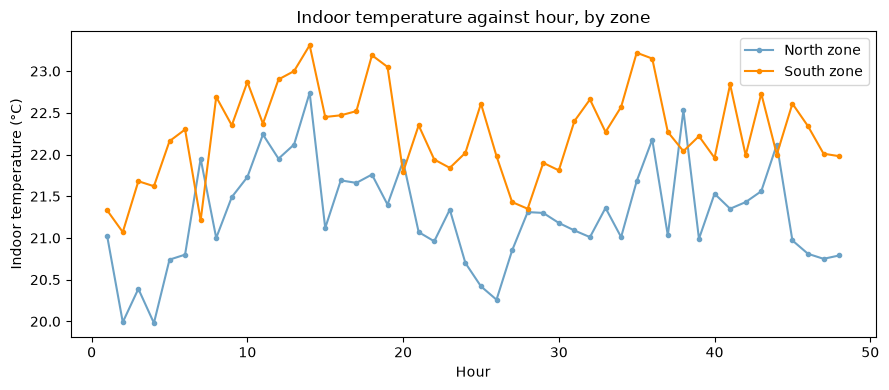

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))

for zone, color in [("north", "#6CA2C6"), ("south", "#FF8C00")]:
    part = df_sb[df_sb["zone"] == zone].sort_values("hour")
    ax.plot(
        part["hour"],
        part["indoor_temp_c"],
        marker=".",
        color=color,
        label=f"{zone.capitalize()} zone",
    )

ax.set_xlabel("Hour")
ax.set_ylabel("Indoor temperature (°C)")
ax.set_title("Indoor temperature against hour, by zone")
ax.legend()
plt.tight_layout()
plt.show()


The horizontal axis shows hour, the sequential hour across the two-day monitoring period, and the vertical axis shows indoor_temp_c in degrees Celsius. The blue line traces the north zone's indoor temperature over time, and the orange line traces the south zone's.

Both zones show a repeating daily cycle across the 48-hour window, completing two full up-and-down cycles that correspond to the two monitored days: temperature dips to its lowest point in the early morning hours and rises to a peak in the afternoon, before falling again into the evening. Throughout almost the entire period, the south zone's line sits above the north zone's line, consistent with south's higher mean and median found earlier. The south line also shows sharper hour-to-hour swings than the more gradual north line. Both lines tend to rise and fall at similar points in time, suggesting the two zones respond to a shared daily driver — most plausibly the outdoor temperature cycle — rather than fluctuating independently.

## 2.3 Outdoor temperature and energy use

c. Create a scatterplot of outdoor_temp_c against energy_kwh, using colour or separate panels for the zones. Describe the direction, form, strength, and unusual points visible in the association.

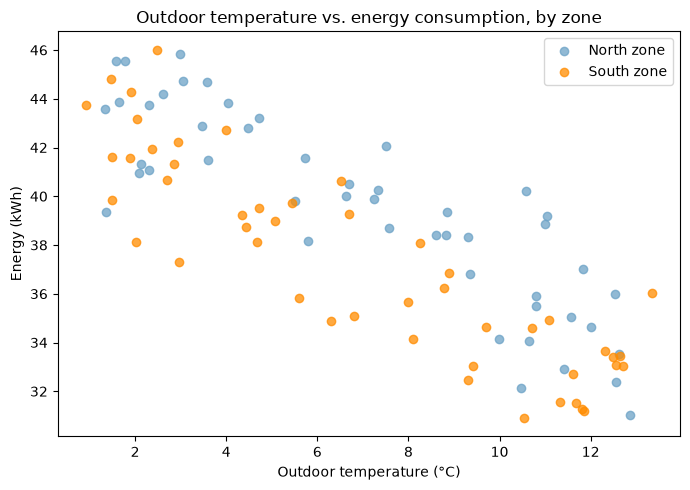

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for zone, color in [("north", "#6CA2C6"), ("south", "#FF8C00")]:
    part = df_sb[df_sb["zone"] == zone]
    ax.scatter(
        part["outdoor_temp_c"],
        part["energy_kwh"],
        color=color,
        label=f"{zone.capitalize()} zone",
        alpha=0.75,
    )

ax.set_xlabel("Outdoor temperature (°C)")
ax.set_ylabel("Energy (kWh)")
ax.set_title("Outdoor temperature vs. energy consumption, by zone")
ax.legend()
plt.tight_layout()
plt.show()

Direction — negative

As outdoor_temp_c increases, energy_kwh decreases, and this holds for both zones. At low outdoor temperatures (around 1–3°C), energy consumption clusters near 42–46 kWh. At high outdoor temperatures (around 12–13°C), energy consumption drops to roughly 31–35 kWh. This pattern is consistent with what would be expected if heating demand rises in colder conditions, though this description alone does not establish causation.

Form — roughly linear

The downward pattern looks like a fairly straight-line decline rather than a curve, plateau, or U-shape. Points fall in a consistent downward band from the upper-left (cold, high energy) to the lower-right (warm, low energy). There is no visible bend or reversal in direction across the observed temperature range.

Strength — moderate

The relationship is visible and consistent, but not tight or perfect. Points are scattered in a fairly wide band around the general downward trend rather than sitting close to a single line. Example: near outdoor temperature ≈8°C, energy values range from about 34 kWh up to nearly 40 kWh — a spread of roughly 6 kWh at essentially the same temperature. This scatter indicates outdoor temperature is an important influence on energy use, but other factors also contribute to the variation.

Unusual points

A north point near outdoor temp ≈10.5°C sits at about 40.2 kWh — noticeably higher than the surrounding cluster of points at similar temperatures (which sit around 32–36 kWh). A south point near outdoor temp ≈13.3°C sits at about 36 kWh — higher than expected given how low other points are at similarly high temperatures (mostly 31–33 kWh nearby). A couple of points around outdoor temp ≈11–12°C dip unusually low, closer to 31 kWh, below the general band of the surrounding cloud. These points don't disrupt the overall pattern, but they are worth naming as visible departures from the general negative trend.

Zone comparison

The north (blue) and south (orange) points are heavily intermixed across the whole plot. Neither zone's cloud sits consistently above or below the other's. This suggests the outdoor-temperature–energy relationship behaves similarly in both zones, rather than one zone being systematically more or less energy-efficient than the other.

## 2.4 Part 2 conclusion

d. Write a short conclusion about temperature stability, differences between zones, and the visible energy–temperature relationship. Do not calculate correlation, fit a regression model, or make causal claims at this stage.

##### Temperature stability

Indoor temperature is fairly stable within each zone across the two-day monitoring window. Both north (sample SD 0.61°C) and south (sample SD 0.55°C) show relatively small hour-to-hour variation, and the run plot shows a smooth, repeating daily cycle rather than erratic jumps — temperature dips in the early morning hours and rises to a peak in the afternoon, in a consistent wave-like pattern across both days.

##### Differences between zones

The two zones differ consistently on both variables. For indoor temperature, south runs about 1°C warmer than north on both mean and median (south: mean 22.27°C, median 22.29°C; north: mean 21.28°C, median 21.24°C), and this gap holds steadily across the full two-day period rather than appearing only at certain hours. Energy consumption shows the opposite ranking: north averages slightly higher energy use than south (39.45 kWh vs. 37.33 kWh), though with somewhat more spread in energy than in indoor temperature for both zones.

##### Visible energy–temperature relationship 

The scatterplot of outdoor temperature against energy consumption shows a clear negative, roughly linear, moderate-strength association in both zones: lower outdoor temperatures are associated with higher energy consumption, and higher outdoor temperatures with lower energy consumption, with the two zones' points closely intermixed rather than forming separate patterns. A few points depart from this general trend, showing higher- or lower-than-expected energy use at a given outdoor temperature, but the overall downward pattern is consistent across the two-day sample. These findings describe only the pattern observed in this specific 48-hour, two-zone sample. The descriptive pattern alone does not establish that outdoor temperature causes the observed change in energy use, nor that the two zones would behave the same way under different conditions or over a longer period.

# Part 3 — Cybersecurity alert system

A security system monitors authentication attempts. $M$ denotes a malicious attempt and $A$ denotes an alert. Historical validation gives:

$$P(M)=0.006,\qquad P(A\mid M)=0.97,\qquad P(A\mid M^c)=0.015$$

We treat these as model probabilities and use $n=100{,}000$ authentication attempts for the natural-frequency table.

## 3.1 Elementary outcomes 
**(a) Define the four elementary outcomes formed from $M, M^c, A, A^c$. Explain why they are mutually exclusive and exhaustive.**

$M$ and $M^c$ split every attempt into exactly two groups: malicious or not malicious. $A$ and $A^c$ split every attempt into exactly two groups: alert or no alert. Combining these two splits gives four elementary outcomes:

- $M\cap A$ - malicious attempt **and** an alert is raised (a correct detection)
- $M\cap A^c$ - malicious attempt **and** no alert is raised (a missed attack)
- $M^c\cap A$ - not malicious **and** an alert is raised (a false alarm)
- $M^c\cap A^c$ - not malicious **and** no alert is raised (nothing happened)

These four outcomes are **mutually exclusive**: one attempt cannot be both malicious and not malicious, and it cannot both trigger an alert and not trigger one, so no attempt can belong to more than one of the four groups at the same time.

They are also **exhaustive**: every attempt is either $M$ or $M^c$, and independently either $A$ or $A^c$, so every attempt must fall into exactly one of the four combinations. There is no other possible outcome.

## 3.2 Expected-count table 
**(b) Construct a labelled 2 x 2 table of expected counts for 100,000 attempts, including row and column totals.**

For $n=100{,}000$ attempts, the two marginal groups are

$$n\cdot P(M)=100{,}000\times0.006=600 \qquad\text{malicious attempts}$$
$$n\cdot P(M^c)=100{,}000\times0.994=99{,}400 \qquad\text{non-malicious attempts}$$

Splitting each group by the conditional alert probabilities gives the four cell counts:

$$600\times0.97=582 \qquad 600\times0.03=18$$
$$99{,}400\times0.015=1{,}491 \qquad 99{,}400\times0.985=97{,}909$$

| | $A$ (alert) | $A^c$ (no alert) | Row total |
|---|---:|---:|---:|
| $M$ (malicious) | 582 | 18 | 600 |
| $M^c$ (not malicious) | 1,491 | 97,909 | 99,400 |
| **Column total** | **2,073** | **97,927** | **100,000** |

Every row and column adds up correctly, so the table is consistent with the two marginal splits.

## 3.3 Probability calculations 
**(c) Use the probability model and verify the results from the table:**

**$P(M\cap A)$** - using the multiplication rule:

$$P(M\cap A)=P(A\mid M)\,P(M)=0.97\times0.006=0.00582$$

Check against the table: $582/100{,}000=0.00582$. ✓

**$P(A)$** - using the law of total probability, because $M$ and $M^c$ partition the sample space:

$$P(A)=P(A\mid M)P(M)+P(A\mid M^c)P(M^c)=(0.97)(0.006)+(0.015)(0.994)$$
$$P(A)=0.00582+0.01491=0.02073$$

Check against the table: $2{,}073/100{,}000=0.02073$. ✓

**$P(M\cup A)$** - using the addition rule:

$$P(M\cup A)=P(M)+P(A)-P(M\cap A)=0.006+0.02073-0.00582=0.02091$$

**$P(M\mid A)$** - using Bayes' theorem:

$$P(M\mid A)=\frac{P(A\mid M)\,P(M)}{P(A)}=\frac{0.00582}{0.02073}\approx0.2808$$

**$P(M^c\mid A)$** - using the complement rule for conditional probability:

$$P(M^c\mid A)=1-P(M\mid A)=1-0.2808=0.7192$$

Check against the table: $1{,}491/2{,}073\approx0.7192$. ✓

So out of every alert the system raises, only about **28%** actually correspond to a real malicious attempt. The remaining **72%** are false alarms, even though the detector itself looks fairly accurate on paper.

## 3.4 Conditional probability, independence and mutual exclusivity 
**(d) Explain the difference between $P(A\mid M)$ and $P(M\mid P)$. Determine whether $M$ and $A$ are independent and whether they are mutually exclusive, justifying both answers numerically.**

**Difference between $P(A\mid M)$ and $P(M\mid A)$:**

$P(A\mid M)=0.97$ is a **forward** probability: given that an attempt is already known to be malicious, how likely is the system to raise an alert. It describes the accuracy of the detector and is fixed by design. 

$P(M\mid A)\approx0.2808$ is the **reverse**, posterior probability: given that an alert has already been observed, how likely is it that the attempt is actually malicious. This is the number a security analyst cares about in practice, because only the alert is observed directly, not the true label. It depends on the detector's accuracy **and** on how rare malicious attempts are to begin with (the base rate $P(M)$), which is why it differs so much from $P(A\mid M)$.

**Independence.** $M$ and $A$ are independent only if $P(M\cap A)=P(M)\,P(A)$. Here

$$P(M)\,P(A)=0.006\times0.02073=0.0001244$$

which is far smaller than the actual value $P(M\cap A)=0.00582$. So $M$ and $A$ are **not independent** — knowing that an alert occurred substantially raises the probability of malicious activity (from the prior $0.006$ up to the posterior $0.2808$).

**Mutual exclusivity.** $M$ and $A$ are **not** mutually exclusive, because $P(M\cap A)=0.00582>0$. The 582 attempts that are both malicious and flagged in the table show directly that the two events can, and do, occur together - this is in fact the outcome the system is designed to produce.

## 3.5 Improved alert system 
**(e) Suppose an improved system reduces $P(A\mid M^c)$ to 0.005 while leaving the other inputs unchanged. Recalculate $P(M\mid A)$, compare it with the original value, and explain why both the false-positive rate and the base rate matter.**

Suppose the false-positive rate is reduced to $P(A\mid M^c)=0.005$, while $P(M)=0.006$ and $P(A\mid M)=0.97$ stay the same.

**New $P(A)$:**

$$P(A)=(0.97)(0.006)+(0.005)(0.994)=0.00582+0.00497=0.01079$$

**New $P(M\mid A)$:**

$$P(M\mid A)=\frac{0.00582}{0.01079}\approx0.5394$$

**Comparison.** The posterior probability that an alert corresponds to a real attack rises from about **28.1%** to about **53.9%**, almost double, even though the malicious attempts themselves and the detector's true-positive rate did not change at all.

**Why both numbers matter.** The base rate of malicious attempts is very low ($0.6\%$), so the group of non-malicious attempts (99,400) is vastly larger than the group of malicious ones (600). Even a small false-positive rate applied to that huge non-malicious group produces a large number of false alarms, and in the original system these false alarms (1,491) outnumbered the true detections (582), which is why $P(M\mid A)$ started so low. Lowering the false-positive rate to 0.5% shrinks the false-alarm count to about 497, while the 582 true detections stay fixed, so the alerts become much more trustworthy.

Even after the improvement, $P(M\mid A)$ is still well below 1, because the non-malicious group is still 99,400 attempts. This shows that both quantities matter together: a detector can look highly accurate (high $P(A\mid M)$, low $P(A\mid M^c)$) and still produce mostly false alarms if the event being detected is rare enough, so the base rate always has to be considered alongside the false-positive rate.


# Part 4 — AI use and overall conclusion

## AI-use statement

| Tool | What it was used for |
|---|---|
| **ChatGPT** | Helped structure the notebook, draft and debug Python code for Parts 1–2, check descriptive calculations, and improve the clarity of written interpretations. |
| **Claude Code** | Helped structure the notebook, draft written text (including the Part 3 probability write-up and the Part 4 conclusion), reviewed teammates' code before merging pull requests, and checked the wording and arithmetic throughout. |
| **GitHub Copilot** | Used on GitHub during pull-request reviews: Copilot was tagged in review comments and asked to apply some of the suggested minor changes (formatting, typos, small fixes) directly to the code. |

**What we changed or rejected:** An early AI suggestion was to drop the observations outside the IQR fences from the dataset; this was rejected because the assignment requires potential outliers to be flagged but kept, not removed. Some AI-generated code initially calculated standard deviation with `ddof=0` (population formula); this was corrected to `ddof=1` to match the required sample standard deviation.

**How we checked correctness:** All code was run against the two supplied CSV files, and the displayed numbers were compared with the formulas introduced in the sessions. Every Part 3 probability calculation was manually cross-checked against the expected-count table. Every group member read through the final notebook.

## Overall conclusion

The three cases illustrate two types of statistical reasoning. Parts 1 and 2 describe observed data: we calculated sample statistics (means, medians, standard deviations, quartiles) from the actual latency and temperature/energy measurements collected, and used plots to see their shape and relationships. Part 3 instead reasoned from an assumed probability model: the alert probabilities were given as fixed values, and every count in the table was derived theoretically from those assumptions, not measured from real attack data.

For the digital services, latency differed clearly across the three services: identity was fastest, orders slowest, and all three distributions were right-skewed with retained potential outliers. A limitation is that the sample's collection process is not described, so results cannot be generalised or explain why the services differ.

For the smart building, indoor temperature was stable within each zone, but south ran about 1°C warmer while north used more energy on average; outdoor temperature and energy showed a negative, moderate, roughly linear pattern. A limitation is that only 48 hours across two zones were observed, so the pattern cannot be assumed to hold long-term, and the relationship does not establish that outdoor temperature causes the change in energy use.

For the alert system, Bayes' theorem showed that even a 97%-accurate detector produces mostly false alarms (P(M|A) ≈ 28%) because malicious attempts are rare; lowering the false-positive rate nearly doubled this to 54%. A limitation is that the conclusion depends entirely on the assumed probabilities being accurate, which was never checked against real data.
